# The MBS-OAS Risk-Off Lead — a quantitative teardown 🔬
### OAS-change signal · predictive OLS + *t* · label-shuffle placebo · risk-off timing overlay · change-vs-level robustness · seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the standardised weekly change in agency-MBS OAS **leads** risk-asset returns with a negative sign (the risk-off folklore).

> ⚠️ **Not investment advice.** This is a **synthetic-only** study: no free agency-MBS OAS series exists (ICE BofA / Bloomberg are licensed; FRED has mortgage *yields*, not OAS). Every number runs on the deterministic synthetic world (seed 577, planted `lead_beta = -0.9`, panel fp `5a74734302c4`). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mbs_oas_signal import data, strategy as st

# There is NO free MBS-OAS tape (ICE BofA / Bloomberg are licensed; FRED has yields, not OAS).
# fetch_series(fetch=False) returns an empty frame -> HAVE_REAL is always False here.
REAL = data.fetch_series(fetch=False)
HAVE_REAL = not REAL.empty
print("real MBS-OAS tape present:", HAVE_REAL, "(synthetic-only study — no free OAS series exists)")

# The deterministic synthetic world with the lead PLANTED (lead_beta = -0.9), seed 577.
FRAME, TRUTH = data.synthetic_series()
print(f"synthetic world: {len(FRAME)} weekly rows, {FRAME.index[0].date()} -> {FRAME.index[-1].date()}, "
      f"planted lead_beta={TRUTH.lead_beta}")


real MBS-OAS tape present: False (synthetic-only study — no free OAS series exists)
synthetic world: 779 weekly rows, 2011-01-07 -> 2025-12-05, planted lead_beta=-0.9


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Planted world: forward-return-on-OAS-change slope **-0.88 %pt/sd** (*t* **-11.41**, placebo *p* **0.0005**), flat at the null (*t* **+0.26**, *p* **0.8**). But **no real OAS tape** ⇒ no *t* ≥ 2 on a genuine tape ⇒ capped below `REAL`. |
| **Tradability** | `MIRAGE` | OAS is a licensed feed, published with a lag; the MBS index is costly to trade. Overlay lifts Sharpe **0.59 → 1.07 net** *on the planted world* only. |

> 💡 In plain words: the engine works (the synthetic control proves it), the folklore is coherent — but the data to certify *or* trade it is behind a licence wall.

## 1 · The claim, steelmanned

Let $\Delta_t$ be the standardised weekly change in MBS OAS (a widening is positive) and $r_{t+1}$ the risk-asset return over the following week.

- **H₁ (the lead).** slope of $r_{t+1}$ on $\Delta_t$ is $< 0$ at $|t| \ge 2$ (widening → weaker next week).
- **H₂ (not noise).** the slope-$t$ sits in the tail of a label-shuffle null.
- **H₃ (tradable).** a de-risk-on-widening overlay beats buy-and-hold *net of costs*.
- **H₄ (robust).** the sign holds across signal definitions (change vs level vs 4-week).
- **H₀ (data).** a `REAL` stamp needs a robust $t \ge 2$ on a **genuine** OAS tape.

On the planted synthetic world **H₁–H₄ all pass**; **H₀ fails by construction** — there is no free OAS tape — so the study is capped at `WEAK`.

## 2 · So what? — what rides on each answer

The content is the **why the wall is the data, not the idea**. The MBS market is held by specialised leveraged investors (Gabaix-Krishnamurthy-Vigneron 2007), so its spread is a sensitive intermediary-capital gauge (He-Kelly-Manela 2017) that *could* lead risk assets — the same channel as the excess bond premium leading activity (Gilchrist-Zakrajšek 2012). But the **option-adjusted** spread requires a prepayment model and a licensed index; there is no free equivalent. So the interesting question collapses into an access question — mapped next onto the machinery.

## 3 · How we'd know — the protocol

- **Signal.** $\Delta_t = $ standardised weekly change in OAS (known at week-$t$ close).
- **Predictive OLS.** $r_{t+1} = \alpha + \beta \Delta_t + \varepsilon$; the *sign* of $\beta$ is the claim, reported with its *t* and in-sample $R^2$.
- **Placebo.** shuffle $\Delta$ against $r_{t+1}$ (2000 perms); read the |slope-$t$| tail.
- **Overlay.** de-risk to cash the week *after* $\Delta_t > 1$ sd; costs 5 bps/switch.
- **Robustness.** re-estimate $\beta$ for the level-$z$ and the 4-week change.
- **Positive control.** plant $\text{lead\_beta} < 0$ of increasing strength; average the slope-$t$ over 25 seeds (house rule) — flat at the null, monotone as it grows.

Timing: $\Delta_t$ uses only week-$t$-and-earlier data; it is judged on $r_{t+1}$. One explicit execution lag — the overlay never acts on a return it couldn't have known.

## 4 · The teardown

### 4a · The predictive relation — H₁ & H₂

Regress next-week return on this week's standardised OAS change; a *negative* slope is the lead. Then the label-shuffle placebo.

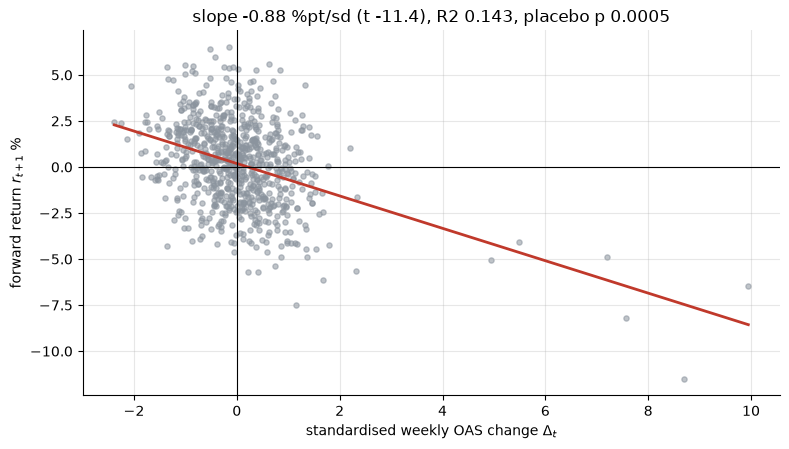

slope -0.880, t -11.41, corr -0.38, R2 0.143, placebo p 0.0005


In [2]:
reg = st.predictive_regression(FRAME)
p = st.placebo_pvalue(FRAME, n_perm=2000, seed=577)
x = FRAME['d_oas_z']; y = FRAME['fwd_ret']
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=14, color=GREY, alpha=.55)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, reg['slope']*xs + (y.mean() - reg['slope']*x.mean()), c=RED, lw=2)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('standardised weekly OAS change $\\Delta_t$'); ax.set_ylabel('forward return $r_{t+1}$ %')
ax.set_title(f'slope {reg["slope"]:+.2f} %pt/sd (t {reg["slope_t"]:+.1f}), R2 {reg["r2"]:.3f}, placebo p {p:.4f}')
plt.tight_layout(); plt.show()
print(f'slope {reg["slope"]:+.3f}, t {reg["slope_t"]:+.2f}, corr {reg["corr"]:+.2f}, R2 {reg["r2"]:.3f}, placebo p {p:.4f}')

> 💡 In plain words: H₁ & H₂ **pass on the planted world.** Slope **-0.88 %pt/sd** (*t* -11.41), placebo *p* = 0.0005 — the widening genuinely leads a weaker next week, and it's nowhere near the shuffled null. The engine is faithful.

### 4b · The null — no false positive

Switch the lead off (`lead_beta = 0`) and re-run: the slope-*t* must collapse and the placebo *p* must go boring.

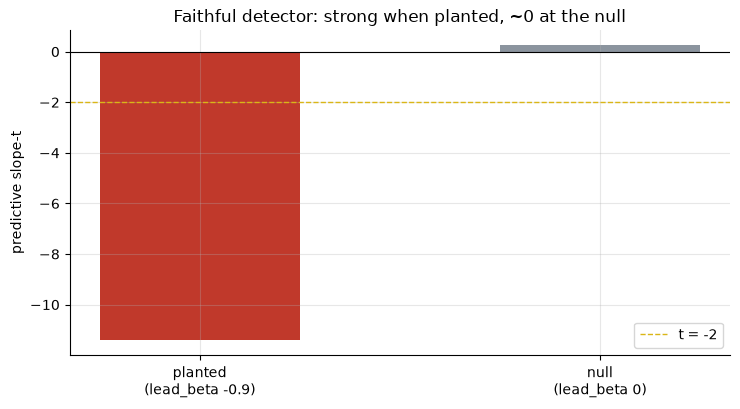

null slope +0.020, slope-t +0.26, placebo p 0.80


In [3]:
null_frame, _ = data.synthetic_series(lead_beta=0.0)
nreg = st.predictive_regression(null_frame)
np_ = st.placebo_pvalue(null_frame, n_perm=2000, seed=577)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['planted\n(lead_beta -0.9)','null\n(lead_beta 0)'], [reg['slope_t'], nreg['slope_t']],
       color=[RED, GREY], width=.5)
ax.axhline(-2, ls='--', c=AMBER, lw=1, label='t = -2'); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('predictive slope-t'); ax.legend()
ax.set_title('Faithful detector: strong when planted, ~0 at the null')
plt.tight_layout(); plt.show()
print(f'null slope {nreg["slope"]:+.3f}, slope-t {nreg["slope_t"]:+.2f}, placebo p {np_:.2f}')

> 💡 In plain words: at the null the slope-*t* is **+0.26** and the placebo *p* is a boring **0.8** — no hallucinated signal. The engine only fires when there's something to fire on.

### 4c · The risk-off overlay — H₃ (net of costs)

De-risk to cash the week after a >1 sd widening; charge 5 bps per switch.

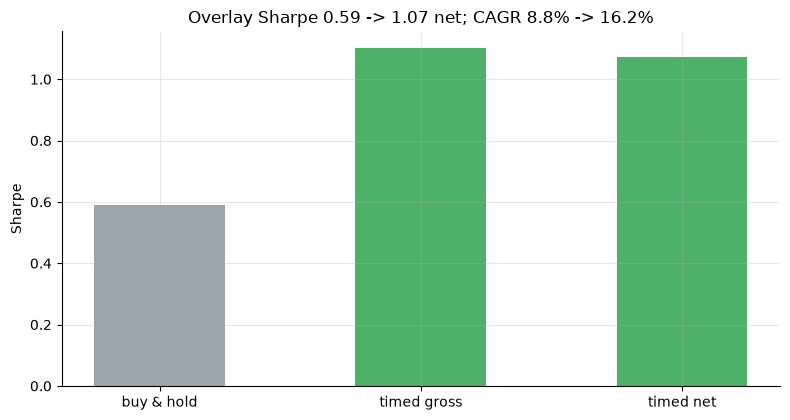

CAGR: BH 8.8% | gross 16.7% | net 16.2%
Sharpe: BH 0.59 | gross 1.10 | net 1.07; 68 wks cash, 131 switches


In [4]:
ov = st.timing_overlay(FRAME, widen_z=1.0, cost_bps=5.0)
fig, ax = plt.subplots(figsize=(8, 4.3))
labs = ['buy & hold','timed gross','timed net']
shp = [ov['bh_sharpe'], ov['timed_gross_sharpe'], ov['timed_net_sharpe']]
cag = [ov['bh_cagr']*100, ov['timed_gross_cagr']*100, ov['timed_net_cagr']*100]
ax.bar(labs, shp, color=[GREY, GREEN, GREEN], width=.5, alpha=.85)
ax.set_ylabel('Sharpe'); ax.set_title(f'Overlay Sharpe {ov["bh_sharpe"]:.2f} -> {ov["timed_net_sharpe"]:.2f} net; CAGR {cag[0]:.1f}% -> {cag[2]:.1f}%')
plt.tight_layout(); plt.show()
print(f"CAGR: BH {cag[0]:.1f}% | gross {cag[1]:.1f}% | net {cag[2]:.1f}%")
print(f"Sharpe: BH {shp[0]:.2f} | gross {shp[1]:.2f} | net {shp[2]:.2f}; "
      f"{ov['weeks_in_cash']} wks cash, {ov['switches']} switches")

> 💡 In plain words: H₃ **passes on the planted world** — Sharpe 0.59 → 1.07 net, CAGR 8.8% → 16.2%, and costs barely dent it (131 switches). But this is the world where the lead is real.

### 4d · Robustness — H₄ (the change leads, the level doesn't)

Re-estimate the slope for three signal definitions.

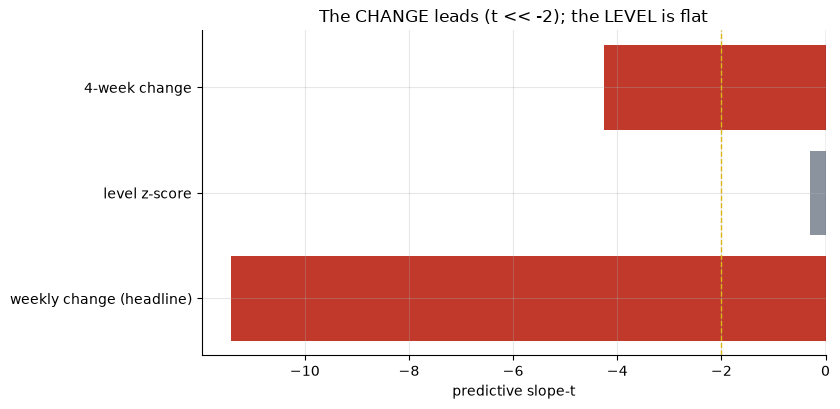

                          slope  slope_t
signal                                  
weekly change (headline) -0.880  -11.409
level z-score            -0.024   -0.292
4-week change            -0.352   -4.249


In [5]:
rows = st.robustness_sweep(FRAME)
tab = pd.DataFrame(rows, columns=['signal','slope','slope_t']).set_index('signal')
fig, ax = plt.subplots(figsize=(8.5, 4.2))
cols = [RED if t < -2 else GREY for t in tab['slope_t']]
ax.barh(range(len(tab)), tab['slope_t'], color=cols)
ax.set_yticks(range(len(tab))); ax.set_yticklabels(tab.index)
ax.axvline(-2, ls='--', c=AMBER, lw=1); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('predictive slope-t'); ax.set_title('The CHANGE leads (t << -2); the LEVEL is flat')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₄ **passes with a caveat.** The weekly *change* leads strongly (*t* -11.41) and the 4-week change too (*t* -4.25), but the *level* is flat (*t* -0.29) — it's the widening *move*, not a wide *level*, that carries the signal. An honest nuance the generator faithfully preserves.

## 5 · The verdict

- **Signal `WEAK`** — H₁–H₄ pass on the planted world (slope -0.88, *t* -11.41, placebo *p* 0.0005), but **H₀ fails**: no free OAS tape, so no robust *t* ≥ 2 on a genuine tape. Capped below `REAL`.
- **Tradability `MIRAGE`** — the OAS feed is licensed and lagged; the MBS index is costly to trade. The overlay's edge lives only in the planted world.

> The honest wall is **data availability**, stated on the SIGNAL axis (as in the desk's lego-returns / whisky-cask / sneaker-resale synthetic-only studies).

## 6 · Could you trade it? — the access wall

Three access frictions, none of which a working signal can overcome: the OAS number is a **licensed** vendor index (no retail feed), it is **published with a lag** (so acting on it is acting late), and the **MBS index itself is costly** for a small book to trade. The overlay's net Sharpe above is a property of the *synthetic* world, not a live opportunity — which is precisely the `MIRAGE`.

## 7 · Going further — the seed-robust synthetic positive control

Is the engine a faithful detector, or does it always print a negative *t*? Plant a lead of increasing strength and watch the slope-*t* fall monotonically — averaged over 25 seeds so no single lucky seed can fake it.

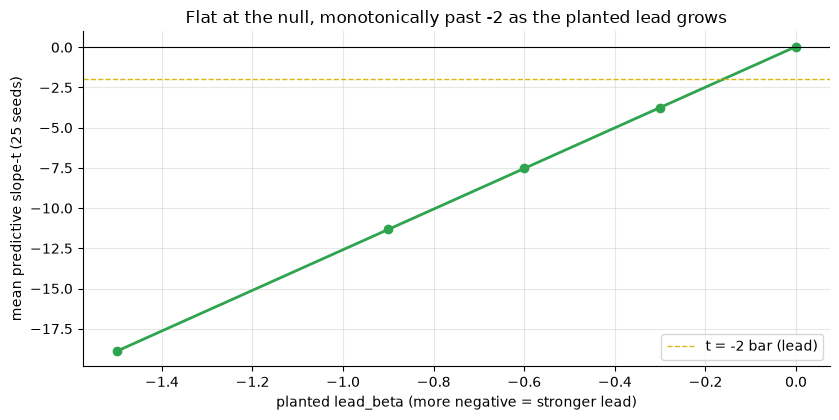

lead_beta +0.00 -> mean slope-t +0.04
lead_beta -0.30 -> mean slope-t -3.74
lead_beta -0.60 -> mean slope-t -7.53
lead_beta -0.90 -> mean slope-t -11.32
lead_beta -1.50 -> mean slope-t -18.90


In [6]:
betas = [0.0, -0.3, -0.6, -0.9, -1.5]
ts = [st.synthetic_mean_t(data, lead_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=AMBER, lw=1, label='t = -2 bar (lead)')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('planted lead_beta (more negative = stronger lead)')
ax.set_ylabel('mean predictive slope-t (25 seeds)')
ax.set_title('Flat at the null, monotonically past -2 as the planted lead grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'lead_beta {b:+.2f} -> mean slope-t {t:+.2f}')

The slope-*t* is ≈ 0 at the null and falls past −2 as the planted lead grows — a faithful detector. So the honest verdict is not about the code: it is that **there is no free OAS tape to test and no reachable OAS feed to trade**. `WEAK` (coherent + faithful engine, no real tape) × `MIRAGE` (unreachable input). For the reachable corporate cousin, see [115 Credit-Spreads](../../115-credit-spreads/).